In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import sys
print(sys.version)

3.10.18 (main, Jun  5 2025, 08:37:47) [Clang 14.0.6 ]


In [3]:
!git clone https://github.com/mannadamay12/tile2net-segD
%cd tile2net-segD

Cloning into 'tile2net-segD'...
remote: Enumerating objects: 2338, done.
remote: Counting objects: 100% (1156/1156), done.
remote: Compressing objects: 100% (307/307), done.
remote: Total 2338 (delta 966), reused 853 (delta 847), pack-reused 1182 (from 2)
Receiving objects: 100% (2338/2338), 7.40 MiB | 6.29 MiB/s, done.
Resolving deltas: 100% (1438/1438), done.
/Users/uttamsingh/Desktop/vizML/tile2net-segD/segmentation-detective/notebooks/tile2net-segD


In [4]:
!pip install -e .

Obtaining file:///Users/uttamsingh/Desktop/vizML/tile2net-segD/segmentation-detective/notebooks/tile2net-segD
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
  Using cached tinycss2-1.4.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached mdurl-0.1.2-py3-none-any.wh

In [5]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

CUDA available: False
GPU: None


In [6]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys

In [7]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 42.6 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=73e4c3a09eadf3156be58d2c87c61397150585488ba701257bef6d1cb425bb7a
  Stored in directory: /Users/uttamsingh/Library/Caches/pip/wheels/3d/b6/be/e13cccebb2aa8855f678b02ad449e803de1dfbe75853c34b3e
Successfully built grad-cam
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [grad-cam]


In [8]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

AttributeError: module 'numpy.linalg._umath_linalg' has no attribute '_ilp64'

In [9]:
!bash ./examples/example.sh < <(echo "")

Please enter the output directory:
Tile generation will now begin.
INFO       NumExpr defaulting to 8 threads.
INFO       NumExpr defaulting to 8 threads.
INFO       Using Massachusetts as the source at location=(42.3536483721, -71.0716891532, 42.3555518995, -71.0643742337)
INFO       Using base_tilesize=256 from source
INFO       Stitching 12 tiles...
INFO       96 tiles missing out of 96 total.
INFO       All 96 tiles are on disk.
           Stitching 6 tiles...                   : 100%|█| 6/6 [00:01<00:00,  5
INFO       Dumping to /var/folders/td/z_6pk1dx5cz1k4pk_jl4c0kw0000gn/T/tile2net/example/tiles/example_256_info.json
INFO       Inferencing. Segmentation results will not be saved.
INFO       Downloading weights for segmentation, this may take a while...
INFO       Weights downloaded.
INFO       Using CPU. This is not recommended for inference.
INFO       Using Per Image based weighted loss
INFO       Using Cross Entropy Loss
INFO       Loading weights from: checkpoint=/Users/ut

In [16]:
import json

city_info_path = "/tmp/tile2net/example/tiles/example_256_info.json"
with open(city_info_path) as f:
    city_info = json.load(f)

# See what keys exist
print("Available keys:")
print(json.dumps(city_info, indent=2))

Available keys:
{
  "name": "example",
  "bbox": [
    42.3519474764,
    42.3560069067,
    -71.0719299316,
    -71.0636901855
  ],
  "location": [
    42.3536483721,
    -71.0716891532,
    42.3555518995,
    -71.0643742337
  ],
  "size": 1024,
  "zoom": 19,
  "crs": 4326,
  "tile_step": 4,
  "project": {
    "config": "/kaggle/working/tile2net-segD/src/tile2net/tileseg/config.py",
    "assets": {
      "weights": {
        "satellite_2021": "/kaggle/working/tile2net-segD/src/tile2net/raster/resources/assets/weights/satellite_2021.pth",
        "hrnetv2_w48_imagenet_pretrained": "/kaggle/working/tile2net-segD/src/tile2net/raster/resources/assets/weights/hrnetv2_w48_imagenet_pretrained.pth"
      }
    },
    "segmentation": "/tmp/tile2net/example/segmentation/example/256_19_4",
    "tiles": {
      "info": "/tmp/tile2net/example/tiles/example_256_info.json",
      "static": "/tmp/tile2net/example/tiles/static/ma/256_19",
      "stitched": "/tmp/tile2net/example/tiles/stitched/256_19_

In [40]:
import sys
import os
sys.path.insert(0, '/kaggle/working/tile2net-segD/src')

import torch
from tile2net.tileseg.network.ocrnet import MscaleOCR
from tile2net.tileseg.config import cfg

# Set config
cfg.MODEL.ARCH = 'ocrnet.HRNet_Mscale'
cfg.DATASET.NUM_CLASSES = 4
cfg.MODEL.OCR.MID_CHANNELS = 512
cfg.MODEL.OCR.KEY_CHANNELS = 256
cfg.MODEL.BNFUNC = torch.nn.BatchNorm2d
cfg.MODEL.HRNET_CHECKPOINT = '/kaggle/working/tile2net-segD/src/tile2net/raster/resources/assets/weights/hrnetv2_w48_imagenet_pretrained.pth'

checkpoint_path = '/kaggle/working/tile2net-segD/src/tile2net/raster/resources/assets/weights/satellite_2021.pth'

# Create model
net = MscaleOCR(num_classes=4, trunk='hrnetv2', criterion=None)

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
state_dict = checkpoint['state_dict']

from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
  name = k[7:] if k.startswith('module.') else k
  new_state_dict[name] = v

net.load_state_dict(new_state_dict)
net = net.cuda().eval()

print("\nModel loaded successfully!")
print(f"Model type: {type(net)}")
print(f"Model on CUDA: {next(net.parameters()).is_cuda}")

INFO       init weights from normal distribution
INFO       loading pretrained model /kaggle/working/tile2net-segD/src/tile2net/raster/resources/assets/weights/hrnetv2_w48_imagenet_pretrained.pth
INFO       Trunk: hrnetv2



✓ Model loaded successfully!
Model type: <class 'tile2net.tileseg.network.ocrnet.MscaleOCR'>
Model on CUDA: True


In [43]:
from pathlib import Path
import os

# Check the specific tile directories
static_dir = Path('/tmp/tile2net/example/tiles/static/ma/256_19')
stitched_dir = Path('/tmp/tile2net/example/tiles/stitched/256_19_4')

print("Static tiles directory:")
print(f"  Path: {static_dir}")
print(f"  Exists: {static_dir.exists()}")
if static_dir.exists():
  files = list(static_dir.iterdir())
  print(f"  Files: {len(files)}")
  if files:
      print(f"  First 5: {[f.name for f in files[:5]]}")
  else:
      print("  (empty directory)")

print("\nStitched tiles directory:")
print(f"  Path: {stitched_dir}")
print(f"  Exists: {stitched_dir.exists()}")
if stitched_dir.exists():
  files = list(stitched_dir.iterdir())
  print(f"  Files: {len(files)}")
  if files:
      print(f"  First 5: {[f.name for f in files[:5]]}")
  else:
      print("  (empty directory)")

# Also check for JPG files
print("\nChecking for other image formats...")
base = Path('/tmp/tile2net/example')
jpgs = list(base.rglob('*.jpg'))
jpegs = list(base.rglob('*.jpeg'))
print(f"  JPG files: {len(jpgs)}")
print(f"  JPEG files: {len(jpegs)}")

if jpgs or jpegs:
  sample = (jpgs + jpegs)[0]
  print(f"  Sample: {sample}")

Static tiles directory:
  Path: /tmp/tile2net/example/tiles/static/ma/256_19
  Exists: True
  Files: 96
  First 5: ['158641_193925.jpg', '158644_193928.jpg', '158642_193925.jpg', '158644_193927.jpg', '158644_193932.jpg']

Stitched tiles directory:
  Path: /tmp/tile2net/example/tiles/stitched/256_19_4
  Exists: True
  Files: 6
  First 5: ['2_1_5.jpg', '0_1_1.jpg', '1_1_3.jpg', '2_0_4.jpg', '1_0_2.jpg']

Checking for other image formats...
  JPG files: 102
  JPEG files: 0
  Sample: /tmp/tile2net/example/tiles/static/ma/256_19/158641_193925.jpg


Loading: /tmp/tile2net/example/tiles/stitched/256_19_4/2_1_5.jpg
Image shape: (1024, 1024, 3)
Image size: (1024, 1024)
Input shape: torch.Size([1, 3, 1024, 1024])
Input range: [-1.912, 2.640]


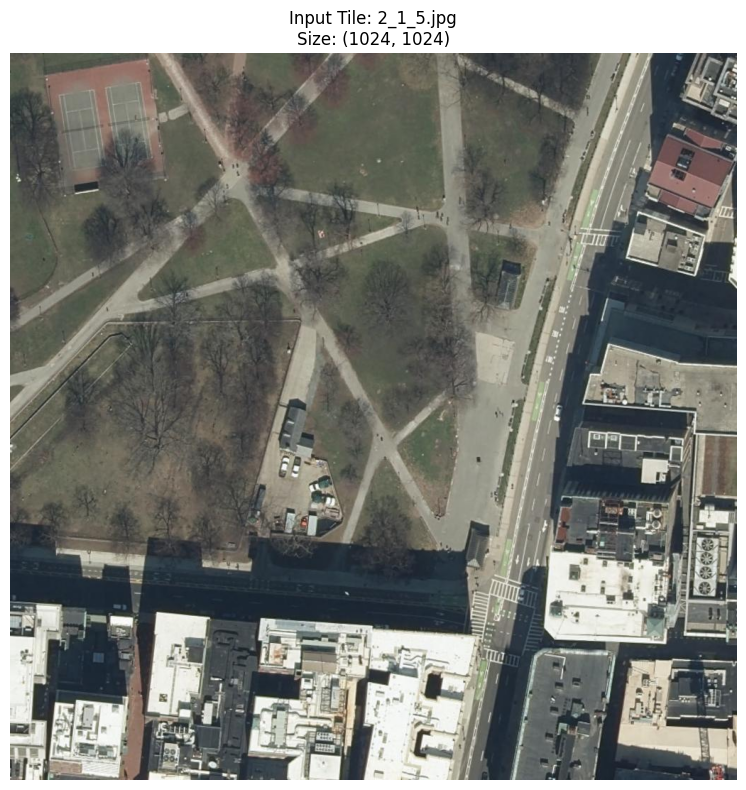

In [44]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from pathlib import Path

# Use stitched tiles (larger, better context)
stitched_dir = Path('/tmp/tile2net/example/tiles/stitched/256_19_4')
tile_path = list(stitched_dir.glob('*.jpg'))[0]

print(f"Loading: {tile_path}")

# Load image
img = Image.open(tile_path).convert('RGB')
img_array = np.array(img)

print(f"Image shape: {img_array.shape}")
print(f"Image size: {img.size}")

# Prepare for model (Tile2Net preprocessing)
img_normalized = img_array.astype(np.float32) / 255.0

transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img).unsqueeze(0).cuda()

print(f"Input shape: {input_tensor.shape}")
print(f"Input range: [{input_tensor.min():.3f}, {input_tensor.max():.3f}]")

# Visualize
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"Input Tile: {tile_path.name}\nSize: {img.size}")
plt.axis('off')
plt.tight_layout()
plt.show()

In [48]:
  # Fix missing config values that are needed for inference
  from tile2net.namespace import torch_version_float

  # Set required config values
  cfg.OPTIONS.TORCH_VERSION = torch_version_float()
  cfg.MODEL.MSCALE = True  # MscaleOCR uses multi-scale
  cfg.MODEL.MSCALE_LO_SCALE = 0.5  # Default low-res scale

  print(f"Torch version: {cfg.OPTIONS.TORCH_VERSION}")
  print(f"Multi-scale enabled: {cfg.MODEL.MSCALE}")
  print(f"Low-res scale: {cfg.MODEL.MSCALE_LO_SCALE}")
  print("\n✓ Config fixed!")

Torch version: 2.6
Multi-scale enabled: True
Low-res scale: 0.5

✓ Config fixed!


Running inference...
Output shape: torch.Size([1, 4, 1024, 1024])


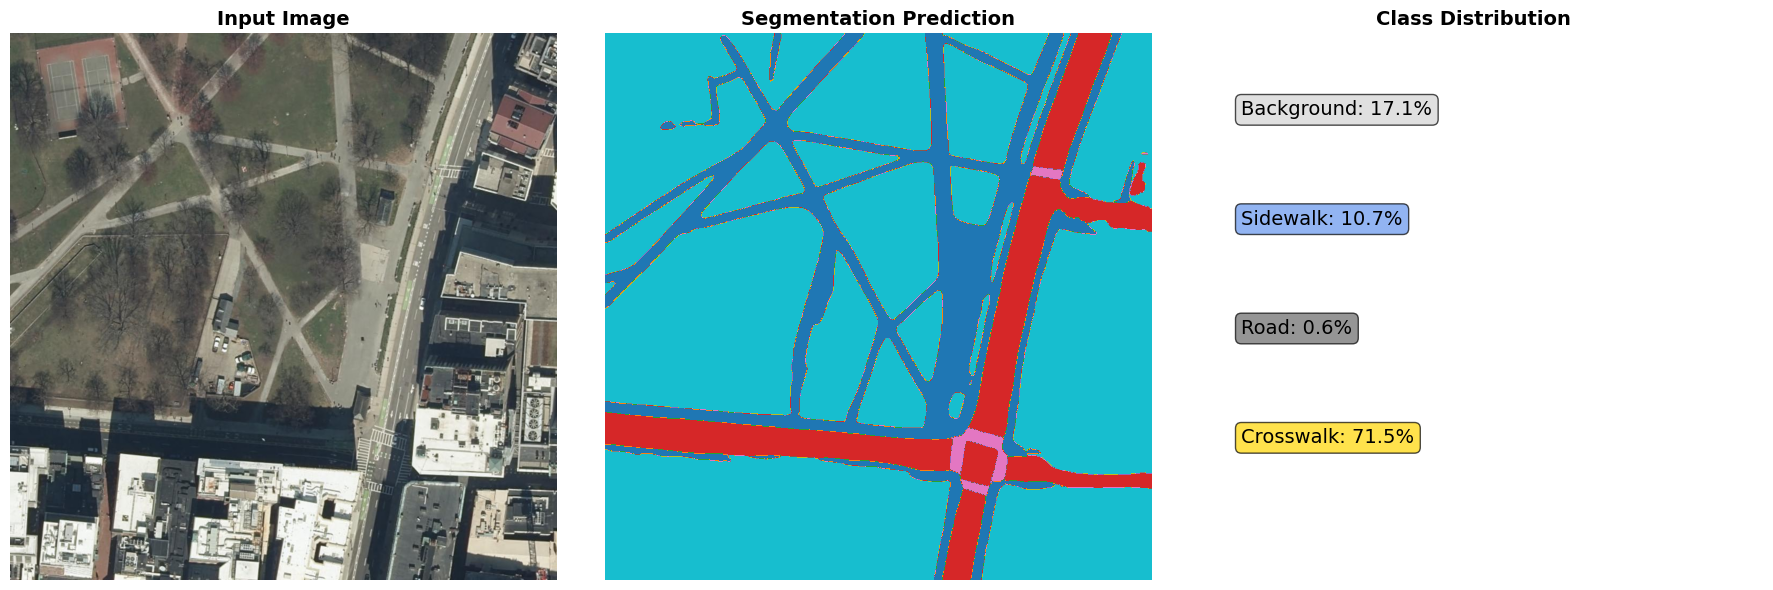


✓ Inference complete!
Unique classes in prediction: [0 1 2 3]


In [49]:
# Run model
print("Running inference...")
with torch.no_grad():
  output = net({'images': input_tensor})

# Handle output
if isinstance(output, dict):
  pred_logits = output.get('pred', output.get('out', list(output.values())[0]))
else:
  pred_logits = output

print(f"Output shape: {pred_logits.shape}")

# Get prediction mask
pred_mask = pred_logits.argmax(dim=1).cpu().numpy()[0]

# Visualize
class_names = ['Background', 'Sidewalk', 'Road', 'Crosswalk']
class_colors = ['lightgray', 'cornflowerblue', 'dimgray', 'gold']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Input
axes[0].imshow(img)
axes[0].set_title('Input Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Prediction
im = axes[1].imshow(pred_mask, cmap='tab10', vmin=0, vmax=3)
axes[1].set_title('Segmentation Prediction', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Stats
axes[2].axis('off')
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
for i in range(4):
  mask = pred_mask == i
  pct = mask.sum() / mask.size * 100
  axes[2].text(0.1, 0.85 - i*0.2,
              f"{class_names[i]}: {pct:.1f}%",
              fontsize=14,
              bbox=dict(boxstyle='round', facecolor=class_colors[i], alpha=0.7,
edgecolor='black'))
axes[2].set_title('Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nInference complete!")
print(f"Unique classes in prediction: {np.unique(pred_mask)}")

In [50]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget

# Inspect HRNet structure
print("=" * 70)
print("HRNet-W48 Backbone Structure for GradCAM")
print("=" * 70)

stage_info = {}
for name, module in net.backbone.named_children():
  if 'stage' in name or 'transition' in name:
      print(f"\n{name}: {type(module).__name__}")
      if hasattr(module, '__len__'):
          print(f"  Num blocks: {len(module)}")
          if 'stage' in name and hasattr(module[-1], 'branches'):
              num_branches = len(module[-1].branches)
              print(f"  Branches: {num_branches} (multi-resolution)")
              stage_info[name] = num_branches
              for i, branch in enumerate(module[-1].branches):
                  print(f"    Branch {i}: {len(branch)} blocks")

print("\n" + "=" * 70)
print("Recommended GradCAM Target Layers:")
print("=" * 70)
print("  stage2: 2 branches (high-res + low-res)")
print("  stage3: 3 branches (high + mid + low res)")
print("  stage4: 4 branches (multi-scale fusion)")
print("\nWe'll visualize how each stage focuses on different features!")
print("=" * 70)

HRNet-W48 Backbone Structure for GradCAM

transition1: ModuleList
  Num blocks: 2

stage2: Sequential
  Num blocks: 1
  Branches: 2 (multi-resolution)
    Branch 0: 4 blocks
    Branch 1: 4 blocks

transition2: ModuleList
  Num blocks: 3

stage3: Sequential
  Num blocks: 4
  Branches: 3 (multi-resolution)
    Branch 0: 4 blocks
    Branch 1: 4 blocks
    Branch 2: 4 blocks

transition3: ModuleList
  Num blocks: 4

stage4: Sequential
  Num blocks: 3
  Branches: 4 (multi-resolution)
    Branch 0: 4 blocks
    Branch 1: 4 blocks
    Branch 2: 4 blocks
    Branch 3: 4 blocks

Recommended GradCAM Target Layers:
  stage2: 2 branches (high-res + low-res)
  stage3: 3 branches (high + mid + low res)
  stage4: 4 branches (multi-scale fusion)

We'll visualize how each stage focuses on different features!


Generating GradCAM for class: Sidewalk
Class coverage: 10.7%
Processing Stage2-HighRes...
Processing Stage2-LowRes...
Processing Stage3-HighRes...
Processing Stage3-MidRes...
Processing Stage4-HighRes...
Processing Stage4-LowRes...


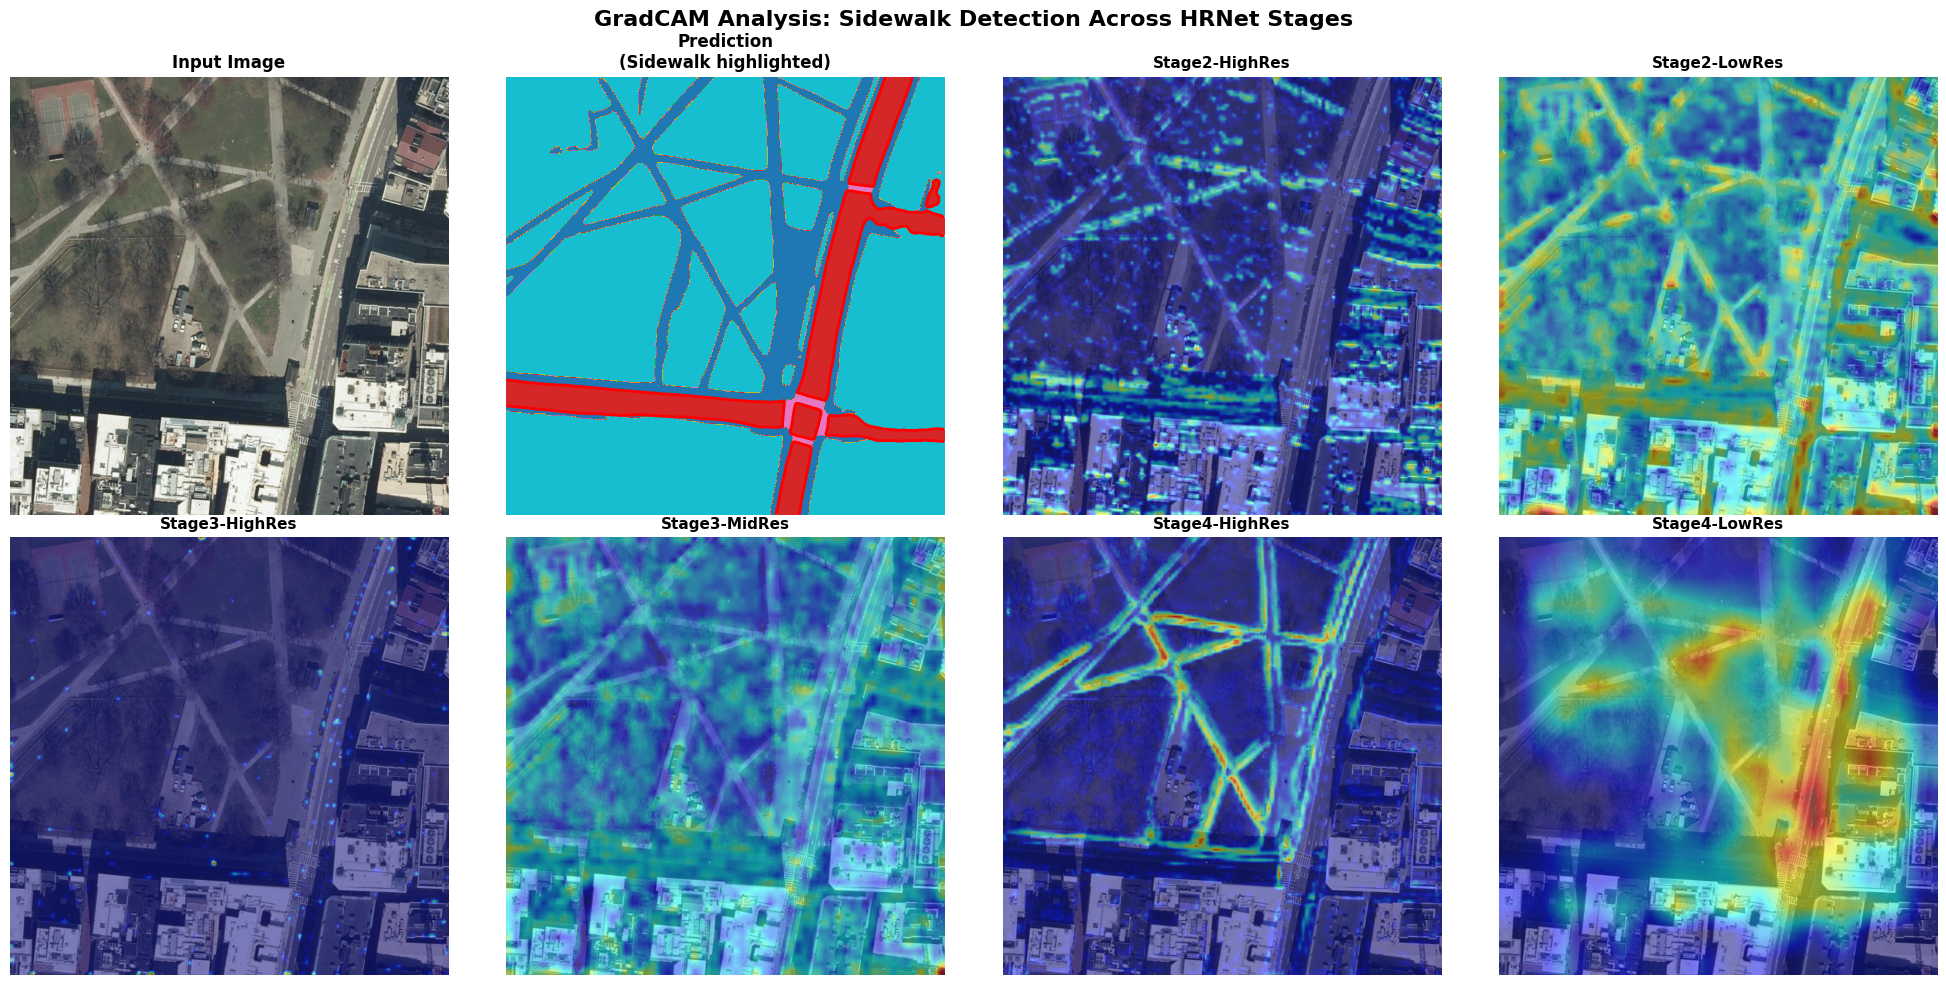


✓ GradCAM visualization complete!


In [54]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch.nn as nn

# Choose a class to explain (1=Sidewalk is usually interesting)
target_class = 1  # Sidewalk
class_mask = (pred_mask == target_class)

print(f"Generating GradCAM for class: {class_names[target_class]}")
print(f"Class coverage: {class_mask.sum() / class_mask.size * 100:.1f}%")

# Create a wrapper model that returns only the prediction tensor
class ModelWrapper(nn.Module):
  def __init__(self, model):
      super().__init__()
      self.model = model

  def forward(self, x):
      output = self.model({'images': x})
      # Return only the prediction logits (what GradCAM expects)
      if isinstance(output, dict):
          return output.get('pred', output.get('out', list(output.values())[0]))
      return output

wrapped_net = ModelWrapper(net)
wrapped_net.eval()

# Copy the backbone reference for GradCAM to access
wrapped_net.backbone = net.backbone

# Define target layers from different HRNet stages
target_layers_dict = {
  'Stage2-HighRes': [wrapped_net.backbone.stage2[-1].branches[0][-1]],
  'Stage2-LowRes': [wrapped_net.backbone.stage2[-1].branches[1][-1]],
  'Stage3-HighRes': [wrapped_net.backbone.stage3[-1].branches[0][-1]],
  'Stage3-MidRes': [wrapped_net.backbone.stage3[-1].branches[1][-1]],
  'Stage4-HighRes': [wrapped_net.backbone.stage4[-1].branches[0][-1]],
  'Stage4-LowRes': [wrapped_net.backbone.stage4[-1].branches[3][-1]],
}

# Prepare target for GradCAM
targets = [SemanticSegmentationTarget(target_class, class_mask)]

# Generate CAMs
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Original image
axes[0].imshow(img)
axes[0].set_title('Input Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Prediction with target class highlighted
axes[1].imshow(pred_mask, cmap='tab10', vmin=0, vmax=3)
axes[1].contour(class_mask, colors='red', linewidths=2)
axes[1].set_title(f'Prediction\n({class_names[target_class]} highlighted)',
               fontsize=12, fontweight='bold')
axes[1].axis('off')

# Generate GradCAM for each layer
for idx, (name, layers) in enumerate(target_layers_dict.items(), start=2):
  print(f"Processing {name}...")

  try:
      cam = GradCAM(model=wrapped_net, target_layers=layers)
      grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

      # Overlay on image
      cam_image = show_cam_on_image(img_normalized, grayscale_cam, use_rgb=True)

      axes[idx].imshow(cam_image)
      axes[idx].set_title(f'{name}', fontsize=11, fontweight='bold')
      axes[idx].axis('off')

      # Clean up
      del cam

  except Exception as e:
      print(f"  Error: {type(e).__name__}: {e}")
      axes[idx].text(0.5, 0.5, f'Error:\n{type(e).__name__}',
                    ha='center', va='center', fontsize=10)
      axes[idx].axis('off')

plt.suptitle(f'GradCAM Analysis: {class_names[target_class]} Detection Across HRNet Stages',
           fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n✓ GradCAM visualization complete!")

In [ ]:
# ============================================================================
# Layer CAM Visualization
# ============================================================================
# Layer CAM generates activation maps by aggregating gradients from multiple
# layers, providing more detailed spatial information than single-layer methods.

from pytorch_grad_cam import LayerCAM
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch.nn as nn

# Choose a class to explain (1=Sidewalk)
target_class = 1  # Sidewalk
class_mask = (pred_mask == target_class)

print(f"Generating Layer CAM for class: {class_names[target_class]}")
print(f"Class coverage: {class_mask.sum() / class_mask.size * 100:.1f}%")

# Prepare target for Layer CAM
targets = [SemanticSegmentationTarget(target_class, class_mask)]

# Define target layers from different HRNet stages
# Layer CAM works well with multiple layers from the same stage
target_layers_dict = {
    'Stage2-MultiLayer': [
        wrapped_net.backbone.stage2[-1].branches[0][-1],
        wrapped_net.backbone.stage2[-1].branches[1][-1]
    ],
    'Stage3-MultiLayer': [
        wrapped_net.backbone.stage3[-1].branches[0][-1],
        wrapped_net.backbone.stage3[-1].branches[1][-1],
        wrapped_net.backbone.stage3[-1].branches[2][-1]
    ],
    'Stage4-MultiLayer': [
        wrapped_net.backbone.stage4[-1].branches[0][-1],
        wrapped_net.backbone.stage4[-1].branches[3][-1]
    ],
}

# Generate Layer CAMs
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Original image
axes[0].imshow(img)
axes[0].set_title('Input Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Prediction with target class highlighted
axes[1].imshow(pred_mask, cmap='tab10', vmin=0, vmax=3)
axes[1].contour(class_mask, colors='red', linewidths=2)
axes[1].set_title(f'Prediction\n({class_names[target_class]} highlighted)',
                  fontsize=14, fontweight='bold')
axes[1].axis('off')

# Generate Layer CAM for each layer group
for idx, (name, layers) in enumerate(target_layers_dict.items(), start=2):
    print(f"Processing {name}...")
    
    try:
        cam = LayerCAM(model=wrapped_net, target_layers=layers)
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        
        # Overlay on image
        cam_image = show_cam_on_image(img_normalized, grayscale_cam, use_rgb=True)
        
        axes[idx].imshow(cam_image)
        axes[idx].set_title(f'Layer CAM: {name}', fontsize=12, fontweight='bold')
        axes[idx].axis('off')
        
        # Clean up
        del cam
        
    except Exception as e:
        print(f"  Error: {type(e).__name__}: {e}")
        axes[idx].text(0.5, 0.5, f'Error:\n{type(e).__name__}',
                      ha='center', va='center', fontsize=10)
        axes[idx].axis('off')

plt.suptitle(f'Layer CAM Analysis: {class_names[target_class]} Detection',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n✓ Layer CAM visualization complete!")


In [ ]:
# ============================================================================
# Score CAM Visualization
# ============================================================================
# Score CAM is a gradient-free method that uses model confidence scores
# to generate activation maps, providing an alternative to gradient-based methods.

from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch.nn as nn

# Choose a class to explain (1=Sidewalk)
target_class = 1  # Sidewalk
class_mask = (pred_mask == target_class)

print(f"Generating Score CAM for class: {class_names[target_class]}")
print(f"Class coverage: {class_mask.sum() / class_mask.size * 100:.1f}%")
print("Note: Score CAM is gradient-free but slower than gradient-based methods...")

# Prepare target for Score CAM
targets = [SemanticSegmentationTarget(target_class, class_mask)]

# Define target layers from different HRNet stages
# Score CAM works with single layers, we'll use high-res branches
target_layers_dict = {
    'Stage2-HighRes': [wrapped_net.backbone.stage2[-1].branches[0][-1]],
    'Stage3-HighRes': [wrapped_net.backbone.stage3[-1].branches[0][-1]],
    'Stage4-HighRes': [wrapped_net.backbone.stage4[-1].branches[0][-1]],
}

# Generate Score CAMs
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Original image
axes[0].imshow(img)
axes[0].set_title('Input Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Prediction with target class highlighted
axes[1].imshow(pred_mask, cmap='tab10', vmin=0, vmax=3)
axes[1].contour(class_mask, colors='red', linewidths=2)
axes[1].set_title(f'Prediction\n({class_names[target_class]} highlighted)',
                  fontsize=14, fontweight='bold')
axes[1].axis('off')

# Generate Score CAM for each layer
for idx, (name, layers) in enumerate(target_layers_dict.items(), start=2):
    print(f"Processing {name}...")
    
    try:
        # Score CAM uses model confidence scores instead of gradients
        cam = ScoreCAM(model=wrapped_net, target_layers=layers)
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        
        # Overlay on image
        cam_image = show_cam_on_image(img_normalized, grayscale_cam, use_rgb=True)
        
        axes[idx].imshow(cam_image)
        axes[idx].set_title(f'Score CAM: {name}', fontsize=12, fontweight='bold')
        axes[idx].axis('off')
        
        # Clean up
        del cam
        
    except Exception as e:
        print(f"  Error: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
        axes[idx].text(0.5, 0.5, f'Error:\n{type(e).__name__}',
                      ha='center', va='center', fontsize=10)
        axes[idx].axis('off')

plt.suptitle(f'Score CAM Analysis: {class_names[target_class]} Detection',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n✓ Score CAM visualization complete!")


In [ ]:
# ============================================================================
# Integrated Gradients Visualization
# ============================================================================
# Integrated Gradients computes attributions by integrating gradients along
# a path from a baseline (e.g., black image) to the input, providing
# pixel-level importance scores.

# Install captum if needed
try:
    import captum
except ImportError:
    print("Installing captum...")
    %pip install captum -q
    import captum

from captum.attr import IntegratedGradients
from captum.attr import visualization as viz
import torch.nn.functional as F

# Choose a class to explain (1=Sidewalk)
target_class = 1  # Sidewalk

print(f"Generating Integrated Gradients for class: {class_names[target_class]}")
print(f"Class coverage: {(pred_mask == target_class).sum() / pred_mask.size * 100:.1f}%")

# Create a wrapper for Integrated Gradients that outputs class-specific logits
class IGWrapper(nn.Module):
    def __init__(self, model, target_class):
        super().__init__()
        self.model = model
        self.target_class = target_class
    
    def forward(self, x):
        output = self.model({'images': x})
        if isinstance(output, dict):
            logits = output.get('pred', output.get('out', list(output.values())[0]))
        else:
            logits = output
        
        # Return logits for the target class only
        # Shape: [batch, height, width]
        return logits[:, self.target_class, :, :]

ig_model = IGWrapper(net, target_class).eval()

# Create baseline (black image with same normalization)
baseline = torch.zeros_like(input_tensor)

# Initialize Integrated Gradients
ig = IntegratedGradients(ig_model)

print("Computing Integrated Gradients (this may take a while)...")

# Compute attributions
# Using n_steps=50 for good balance between accuracy and speed
attributions = ig.attribute(
    input_tensor,
    baselines=baseline,
    target=None,  # Using class-specific wrapper instead
    n_steps=50,
    internal_batch_size=1
)

# Convert to numpy for visualization
attributions_np = attributions.squeeze().cpu().detach().numpy()
# Sum across channels to get a single attribution map
if len(attributions_np.shape) == 3:
    attributions_np = np.sum(attributions_np, axis=0)

# Normalize attributions
attributions_np = np.maximum(attributions_np, 0)  # Remove negative values
if attributions_np.max() > 0:
    attributions_np = attributions_np / attributions_np.max()

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original image
axes[0, 0].imshow(img)
axes[0, 0].set_title('Input Image', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# Prediction with target class highlighted
axes[0, 1].imshow(pred_mask, cmap='tab10', vmin=0, vmax=3)
axes[0, 1].contour((pred_mask == target_class), colors='red', linewidths=2)
axes[0, 1].set_title(f'Prediction\n({class_names[target_class]} highlighted)',
                     fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

# Integrated Gradients heatmap
im1 = axes[0, 2].imshow(attributions_np, cmap='hot', interpolation='bilinear')
axes[0, 2].set_title('Integrated Gradients\n(Attribution Heatmap)',
                     fontsize=14, fontweight='bold')
axes[0, 2].axis('off')
plt.colorbar(im1, ax=axes[0, 2], fraction=0.046, pad=0.04)

# Overlay on original image
axes[1, 0].imshow(img)
axes[1, 0].imshow(attributions_np, cmap='hot', alpha=0.6, interpolation='bilinear')
axes[1, 0].set_title('IG Overlay\n(Original + Attribution)',
                     fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

# Positive attributions only (highlighting important regions)
positive_attr = np.maximum(attributions_np, 0)
axes[1, 1].imshow(img)
axes[1, 1].imshow(positive_attr, cmap='jet', alpha=0.5, interpolation='bilinear')
axes[1, 1].set_title('IG Positive Attribution\n(Important Regions)',
                     fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

# Thresholded attribution (top 20% most important pixels)
threshold = np.percentile(attributions_np, 80)
thresholded_attr = attributions_np.copy()
thresholded_attr[thresholded_attr < threshold] = 0
axes[1, 2].imshow(img)
axes[1, 2].imshow(thresholded_attr, cmap='hot', alpha=0.7, interpolation='bilinear')
axes[1, 2].set_title('IG Top 20% Attribution\n(Most Important Pixels)',
                     fontsize=14, fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle(f'Integrated Gradients Analysis: {class_names[target_class]} Detection',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"\nAttribution statistics:")
print(f"  Min: {attributions_np.min():.4f}")
print(f"  Max: {attributions_np.max():.4f}")
print(f"  Mean: {attributions_np.mean():.4f}")
print(f"  Std: {attributions_np.std():.4f}")
print(f"\n✓ Integrated Gradients visualization complete!")
